In [319]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [320]:
infile = r"C:\Users\seifert\Pictures\Temp\Out\ResultTotal_5\res.csv"
df = pd.read_csv(infile, sep=';')

In [321]:
d = dict(df)

In [322]:
d.keys()

dict_keys(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn', 'p1', 'p2', 'cat', 'conf', 'w_px', 'h_px', 'mid_x_nm', 'mid_y_nm', 'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm', 'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm', 'long_axis_nm', 'short_axis_nm', 'angle'])

In [323]:
%matplotlib inline

In [324]:
ids = np.unique(d['img_id'])

In [325]:
def get_dict_from_id(img_id):
    retd = {}
    idcs = []
    for num, i in tqdm(enumerate(d['img_id'])):
        if i == img_id:
            idcs.append(num)

    for key in d.keys():
        retd[key] = []
        for num, val in enumerate(d[key]):
            if num in idcs:
                retd[key].append(val)


    return retd

In [326]:
dict_0 = get_dict_from_id(0)

2256it [00:00, 2221730.41it/s]


In [327]:
dict_0

{'Unnamed: 0': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 'total_id': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 'img_id': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'crop_id': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38

In [328]:
midpoints_x = [x for x in dict_0['mid_x_nm']]
midpoints_y = [x for x in dict_0['mid_y_nm']]
centroid_x = [x for x in dict_0['centroid_x_nm']]
centroid_y = [x for x in dict_0['centroid_y_nm']]
confidences = [x for x in dict_0['conf']]


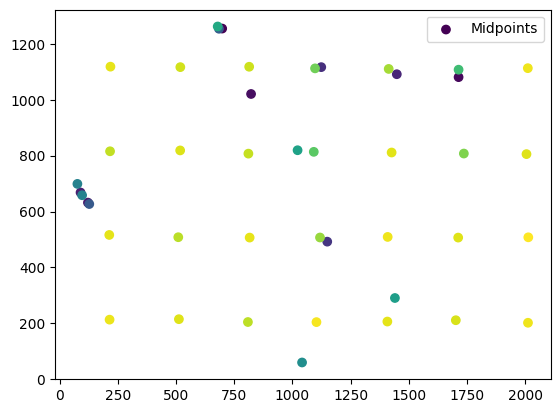

In [329]:
plt.scatter(midpoints_x, midpoints_y, c=confidences, label='Midpoints')
plt.legend()

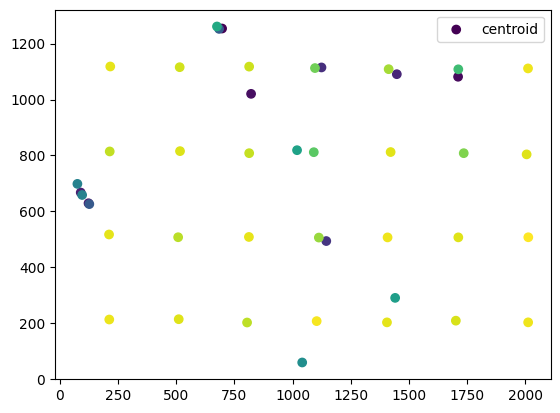

In [330]:
plt.scatter(centroid_x, centroid_y, c=confidences, label='centroid')
plt.legend()

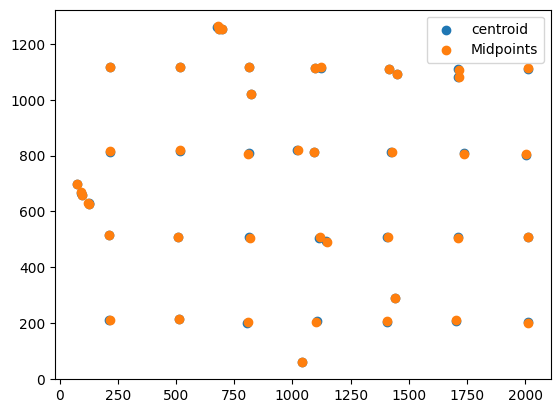

In [331]:
plt.scatter(centroid_x, centroid_y, label='centroid')
plt.scatter(midpoints_x, midpoints_y, label='Midpoints')
plt.legend()

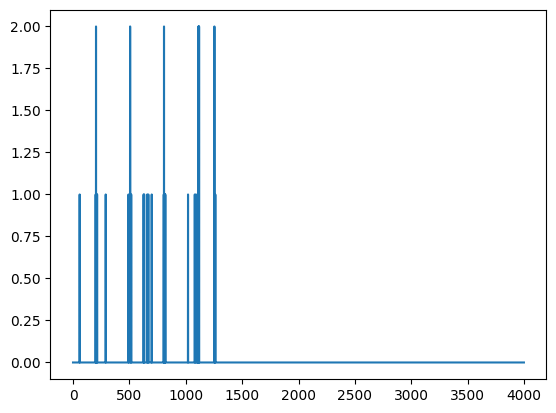

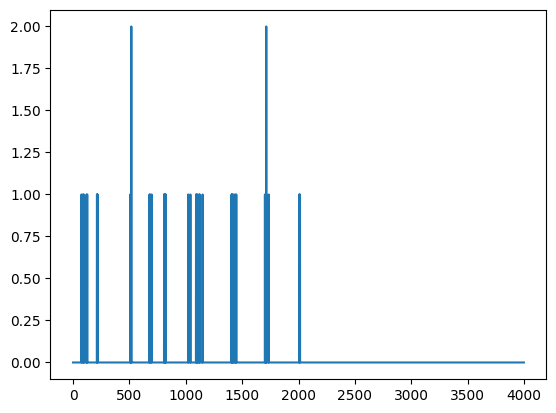

In [332]:
arr = np.zeros((4000, 4000))
x = midpoints_x
y = midpoints_y
for pt in zip(x, y):
    xpos = int(pt[0])
    ypos = int(pt[1])
    arr[xpos, ypos] += 1

# plt.imshow(arr)

x_axis = np.sum(arr, axis=0)
plt.plot(x_axis)
plt.show()

y_axis = np.sum(arr, axis=1)
plt.plot(y_axis)
plt.show()

In [333]:
from IPython import display
import pylab as pl

def itplot(x, y):
    pl.plot(x, y, c='gray')
    display.clear_output(wait=True)
    display.display(pl.gcf())

In [418]:
pairs_x = list(zip(centroid_x, confidences))
pairs_x = sorted(pairs_x, key=lambda x : x[0])

pairs_y = list(zip(centroid_y, confidences))
pairs_y = sorted(pairs_y, key=lambda x : x[0])

x_values = [e[0] for e in pairs_x]
x_conf = [e[1] for e in pairs_x]

y_values = [e[0] for e in pairs_y]
y_conf = [e[1] for e in pairs_y]

In [419]:
periods = [1, 2, 3, 4, 5, 6, 7, 8, 9]
mind = 50
def find_qmat(vals, cnfs, pers):
    qualities = 0 * np.ones((len(vals), len(vals), len(pers)))
    for idx1, kp1 in tqdm(enumerate(vals)):
        for idx2, kp2 in enumerate(vals):
            dist = abs(kp1 - kp2)
            if dist <= mind:
                continue
            for idx3, per in enumerate(pers):
                loc_per = dist / per
                loc_qual = 0
                for kp3, conf in zip(vals, cnfs):
                    d = np.amin([abs(kp3 - x * loc_per) for x in range(-10, 10)])
                    d = d / np.sqrt(loc_per)

                    #d = abs((kp3 - kp1))
                    #no_per = round( (kp3 - kp1) / loc_per)
                    #peri_kp = kp1  + no_per * loc_per
                    #peri_kp_dist = abs(d - peri_kp)
                    # rel_pkd = peri_kp_dist / loc_per
                    #rel_pkd = peri_kp_dist
                    loc_qual += conf * d

                qualities[idx1, idx2, idx3] = loc_qual

    qualities[qualities == 0] = np.nan
    qualities[4:-4, 4:-4, :] = np.nan
    return qualities

In [420]:
mind = 50


In [421]:
# %matplotlib qt
%matplotlib inline

In [422]:
qualities = find_qmat(x_values, x_conf, periods)

44it [00:04, 10.86it/s]


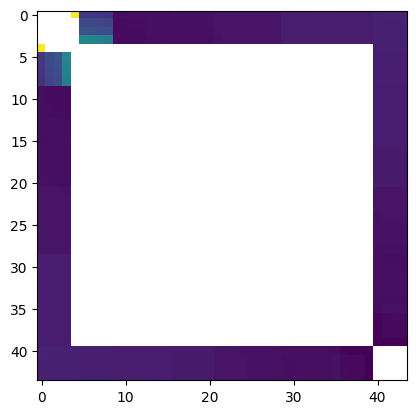

In [423]:
plt.imshow(qualities[:, :, 0], cmap='viridis')

In [424]:
qualities.shape

(44, 44, 9)

In [425]:
qualities[np.isnan(qualities)] = np.inf

In [426]:
best_pos_x = np.unravel_index(np.argmin(qualities, axis=None), qualities.shape)
best_pos_x

(33, 40, 1)

In [427]:
# best_pos_x = (5, -1, 5)

In [428]:
kp1_x = x_values[best_pos_x[0]]
kp2_x = x_values[best_pos_x[1]]
dist = abs(kp1_x - kp2_x)
period_x = dist / periods[best_pos_x[2]]
period_x

282.498226102961

In [429]:
qualities[best_pos_x]

83.49483959457054

In [430]:
grids_x = []
for i in range(-100, 100):
    if 0 < kp1_x + i * period_x < 1.2 * max(x_values):
        grids_x.append( kp1_x + i * period_x)

In [431]:
qualities_y = find_qmat(y_values, y_conf, periods)


44it [00:03, 11.26it/s]


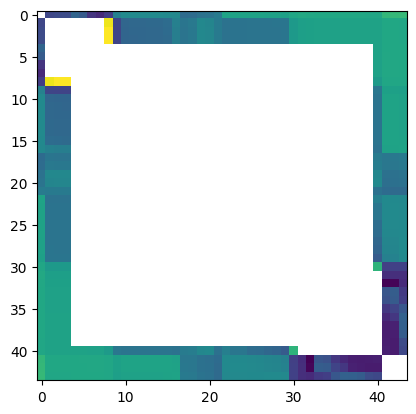

In [432]:
plt.imshow(qualities_y[:, :, 0], cmap='viridis')


In [433]:
qualities_y[np.isnan(qualities_y)] = np.inf

In [434]:
best_pos_y = np.unravel_index(np.argmin(qualities_y, axis=None), qualities_y.shape)
best_pos_y

(8, 42, 5)

In [435]:
qualities_y[best_pos_y]


61.35332582506815

In [436]:
kp1_y = y_values[best_pos_y[0]]
kp2_y = y_values[best_pos_y[1]]
dist = abs(kp1_y - kp2_y)
period_y = dist / periods[best_pos_y[2]]
period_y

160.57980530610823

In [437]:
grids_y = []
for i in range(-100, 100):
    if 0 < kp1_y + i * period_y < 1.2 * max(y_values):
        grids_y.append( kp1_y + i * period_y)

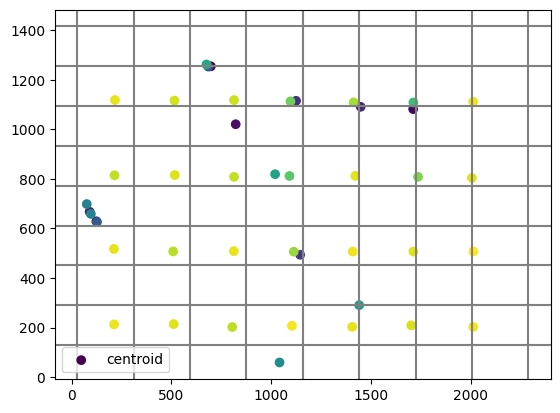

In [438]:
plt.scatter(centroid_x, centroid_y, c=confidences, label='centroid')
for gx in grids_x:
    plt.axvline(x=gx, color='gray')
for gy in grids_y:
    plt.axhline(y=gy, color='gray')
plt.legend()